# Hafta 5 · Ders 9 — Özdeğerler ve Özvektörler

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Şimdiye kadar bir matris vektörleri *hareket ettirdi*. Ama neredeyse her matris için, onu
**döndürmediği** özel yönler vardır — yalnızca onları gerer ya da büzer. Bunlar
**özvektörlerdir** ve gerilme çarpanları **özdeğerlerdir**:

$$ A\mathbf{v} = \lambda \mathbf{v} $$

Özvektörler, bir dönüşümün doğal koordinat sistemidir. Onları bulmak, bir matrisi **köşegenleştirmemizi**,
ucuza kuvvetlerini almamızı ve — makine öğrenmesine hâkim olan simetrik matrisler için — temiz bir
ortogonal eksen kümesi garantilememizi sağlar. Bu, PCA ve SVD'nin üzerine kurulduğu kavramsal çekirdektir.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import plot_vectors_2d, check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Özvektörleri görmek

Bir özvektör, matrisin koruduğu bir yönü gösterir. $A$'yı bir vektör halkasına uygulayın: çoğu
döndürülür, ama özvektörler kendi doğruları üzerinde kalır (yalnızca uzunlukları değişir). Hadi onu çizelim.

eigenvalues : [3. 1.]
eigenvectors (columns):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


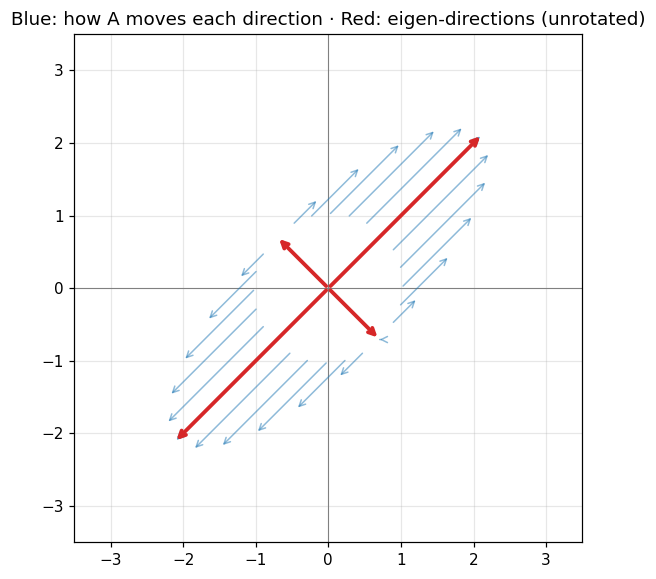

In [2]:
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
vals, vecs = np.linalg.eig(A)
print("özdeğerler :", vals)
print("özvektörler (sütunlar):\n", vecs)

th = np.linspace(0, 2*np.pi, 24, endpoint=False)
ring = np.stack([np.cos(th), np.sin(th)])
out = A @ ring

fig, ax = plt.subplots(figsize=(6, 6))
for i in range(ring.shape[1]):
    ax.annotate("", xy=out[:, i], xytext=ring[:, i],
                arrowprops=dict(arrowstyle="->", color="C0", alpha=0.5, lw=1))
for k in range(2):
    v = vecs[:, k] * vals[k]
    ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
    ax.annotate("", xy=-v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
ax.axhline(0, color="grey", lw=0.7); ax.axvline(0, color="grey", lw=0.7)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.set_title("Mavi: A her yönü nasıl hareket ettirir · Kırmızı: öz-yönler (döndürülmemiş)")
plt.show()

## 2. Nereden gelirler: karakteristik denklem

$A\mathbf{v} = \lambda\mathbf{v}$, $(A - \lambda I)\mathbf{v} = \mathbf{0}$'a yeniden düzenlenir.
Sıfır olmayan bir $\mathbf{v}$, ancak $A - \lambda I$ uzayı çökerttiğinde — yani determinantı yok
olduğunda — vardır:

$$ \det(A - \lambda I) = 0 $$

Bu **karakteristik polinom**, özdeğerleri kökleri olarak içerir. $2\times 2$ matrisler için onu
elle çözebilir ve Ders 3'ten iki dosta bağlayabiliriz: özdeğerler **ize (trace)** toplanır ve
**determinanta** çarpılır.

In [3]:
def eig_2x2(A):
    (a, b), (c, d) = A
    tr = a + d                      # = özdeğerlerin toplamı
    det = a * d - b * c             # = özdeğerlerin çarpımı
    disc = np.sqrt(tr**2 - 4*det + 0j)
    l1 = (tr + disc) / 2
    l2 = (tr - disc) / 2
    return np.array([l1, l2])

A = np.array([[2.0, 1.0], [1.0, 2.0]])
mine = np.sort_complex(eig_2x2(A))
ref = np.sort_complex(np.linalg.eigvals(A))
check("2×2 özdeğerler", mine, ref)
print("iz =", np.trace(A), " = toplam λ =", round(eig_2x2(A).real.sum(), 4))
print("det =", round(np.linalg.det(A), 4), " = çarpım λ =", round(np.prod(eig_2x2(A)).real, 4))

[PASS] 2×2 eigenvalues                  max|Δ| = 0.00e+00
trace = 4.0  = sum λ = 4.0
det   = 3.0  = prod λ = 3.0


## 3. Köşegenleştirme: doğal koordinatlar olarak özbaz

$A$'nın tam bir bağımsız özvektör kümesi varsa, onları $V$'ye ve özdeğerleri köşegen bir $\Lambda$'ya
üst üste koymak şunu verir

$$ A = V \Lambda V^{-1} $$

Özbazda, dönüşüm *yalnızca her ekseni ölçeklemektir* — tüm karmaşıklık bir kılıktı. Bu, kuvvetleri
önemsiz yapar: $A^k = V\Lambda^k V^{-1}$, çünkü $\Lambda^k$ yalnızca köşegeni kuvvetlendirir. Bu
kısayol, kuvvet yönteminin ve Markov-zinciri kararlı durumlarının arkasındaki motordur.

In [4]:
vals, V = np.linalg.eig(A)
Lam = np.diag(vals)
check("A == V Λ V⁻¹", V @ Lam @ np.linalg.inv(V), A, atol=1e-10)

# özbaz aracılığıyla ucuz matris kuvveti
k = 5
A_pow_eig = (V @ np.diag(vals**k) @ np.linalg.inv(V)).real
A_pow_direct = np.linalg.matrix_power(A, k)
check(f"özbaz aracılığıyla A^{k}", A_pow_eig, A_pow_direct, atol=1e-6)

[PASS] A == V Λ V⁻¹                     max|Δ| = 0.00e+00
[PASS] A^5 via eigenbasis               max|Δ| = 0.00e+00


True

## 4. Simetrik matrisler: spektral teorem

Makine öğrenmesi **simetrik** matrislerle doludur — kovaryans matrisleri, Gram matrisleri, Hessian'lar.
Bunlar özeldir:

> **Spektral teorem:** reel bir simetrik matrisin *reel* özdeğerleri ve *tam ortonormal* bir özvektör
> kümesi vardır. Yani $A = Q\Lambda Q^\top$; $Q$ ortogonaldir.

Dağınık ters yok — yalnızca bir transpoz, Hafta 4'ün ortogonalliği sayesinde. Bu, tam olarak PCA'in
kovaryans matrisinde kullandığı yapıdır ve PCA'in bileşenlerinin neden bedavaya ortogonal çıktığının nedenidir.

In [5]:
rng = np.random.default_rng(0)
M = rng.normal(size=(4, 4))
S = M + M.T                                   # simetriyi zorla

vals, Q = np.linalg.eigh(S)                   # eigh: simetrik/Hermityen için
print("özdeğerler (hepsi reel):", vals)
check("Q ortogonal: QᵀQ == I", Q.T @ Q, np.eye(4), atol=1e-10)
check("S == Q Λ Qᵀ", Q @ np.diag(vals) @ Q.T, S, atol=1e-10)

eigenvalues (all real): [-3.4957 -0.9039  0.2303  2.4328]
[PASS] Q orthogonal: QᵀQ == I           max|Δ| = 4.44e-16
[PASS] S == Q Λ Qᵀ                      max|Δ| = 1.33e-15


True

## 5. Bunun makine öğrenmesinde karşımıza çıktığı yer

- **PCA** = kovaryans matrisinin özayrışımı; özvektörler temel yönlerdir, özdeğerler onlar boyunca
  varyanstır (Hafta 6).
- **PageRank** = bir web-bağlantı matrisinin baskın özvektörü (sonraki ders).
- **Spektral kümeleme**, toplulukları bulmak için bir çizge Laplacian'ının özvektörlerini kullanır.
- **Hessian'ın özdeğerleri**, bir kayıp yüzeyinin eğriliğini tanımlar — gradyan inişinin ne kadar
  hızlı yakınsadığını ve bir kritik noktanın min, maks ya da eyer olup olmadığını yönetirler.

Ön gösterim: bir veri kovaryans matrisinin özvektörleri, veri bulutunun eksenlerinin *kendisidir*.

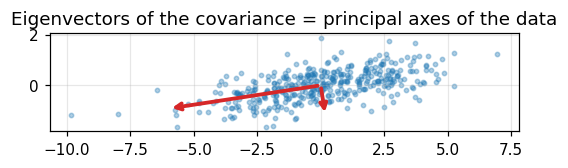

variance along each principal axis (eigenvalues): [0.2281 5.854 ]


In [6]:
rng = np.random.default_rng(1)
data = rng.normal(size=(400, 2)) @ np.array([[2.0, 0.0], [1.5, 0.6]])
data -= data.mean(0)
cov = (data.T @ data) / len(data)
vals, vecs = np.linalg.eigh(cov)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(data[:, 0], data[:, 1], s=8, alpha=0.35, color="C0")
for k in range(2):
    v = vecs[:, k] * np.sqrt(vals[k]) * 2.5    # görünürlük için std ile ölçekle
    plt.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
plt.gca().set_aspect("equal"); plt.grid(True, alpha=0.3)
plt.title("Kovaryansın özvektörleri = verinin temel eksenleri")
plt.show()
print("her temel eksen boyunca varyans (özdeğerler):", vals)

## Alıştırmalar

1. **Karmaşık özdeğerler.** Saf bir döndürme matrisinin reel özvektörü yoktur. Bir 90° döndürmenin özdeğerlerini hesaplayın ve karmaşık sonucu yorumlayın.
2. **Tekrarlı özdeğerler.** Tekrarlı bir özdeğeri ama yalnızca bir özvektörü olan bir matris oluşturun ("kusurlu" bir matris). Neden köşegenleştirilemez?
3. **İz ve det kısayolu.** Özvektörleri hesaplamadan, iz ve determinant kullanarak $\begin{psmallmatrix}3&1\\0&3\end{psmallmatrix}$'in özdeğerlerini bulun ve püf noktasını açıklayın.

In [7]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. 90° döndürme: özdeğerler ±i'dir (reel öz-yön yok — her şey döner)
R = np.array([[0.0, -1.0], [1.0, 0.0]])
print("90° döndürme özdeğerleri:", np.linalg.eigvals(R), " → tamamen sanal")

# 2. kusurlu matris [[2,1],[0,2]]: özdeğer 2 (iki kez) ama tek bir özvektör
D = np.array([[2.0, 1.0], [0.0, 2.0]])
w, v = np.linalg.eig(D)
print("\nkusurlu özdeğerler:", w)
print("özvektörler (neredeyse paralel → tam bir baz değil):\n", v)

# 3. iz=6, det=9 ⇒ λ²−6λ+9=0 ⇒ (λ−3)²=0 ⇒ λ=3 (tekrarlı). Püf noktası: kusurludur.

90° rotation eigenvalues: [0.+1.j 0.-1.j]  → purely imaginary

defective eigenvalues: [2. 2.]
eigenvectors (nearly parallel → not a full basis):
 [[ 1. -1.]
 [ 0.  0.]]


## Özet ve sırada ne var

Özvektörler, bir matrisin yalnızca ölçeklediği yönlerdir; özdeğerler ölçek çarpanlarıdır. Köşegenleştirme
$A = V\Lambda V^{-1}$, kılık değiştirmiş ölçeklemeyi ortaya çıkarır ve simetrik matrisler için spektral
teorem bize ortonormal bir özbaz $A = Q\Lambda Q^\top$ verir.

**Sırada — `10_kuvvet_yontemi_qr_iterasyonu.ipynb`:** `np.linalg.eig`'i *çağırmayı* bırakıp özdeğerleri
gerçekten hesaplayan algoritmaları inşa ediyoruz — kuvvet yöntemi ve QR iterasyonu — sonra onları
PageRank'e uyguluyoruz.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 5 · Ders 9*